# HAL-TMLE Right-Censored Target Learning

This notebook is the right-censored analogue of `examples/example_full_data_target_learning.ipynb`.

It does two things:

1. a single-target walkthrough driven by `TARGET_TYPE`
2. a batch demonstration and small Monte Carlo run across all four right-censored targets

The four targets are:

- `Survival`
- `RMST`
- `DensitySquare`
- `Entropy`

The demo uses the updated right-censored targeting defaults:

- censoring generated from `Unif[0, 1.2]`
- `CV-IPCW-L1MLE` as the initial estimator
- no cheat mode
- targeting `Gbar` truncated at order `1 / (sqrt(n) log n)`
- automatic targeting that checks the initial EIF score before taking any TMLE step


In [1]:
import sys
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

CANDIDATES = [
    pathlib.Path.cwd().resolve(),
    pathlib.Path('/Users/houyilong/GitHub/HALDensity/examples/HAL-TMLE-RC'),
]
for candidate in CANDIDATES:
    if (candidate / 'rc_target_learning_demo_utils.py').exists():
        NOTEBOOK_DIR = candidate
        break
else:
    raise FileNotFoundError('Could not find rc_target_learning_demo_utils.py')

ROOT = NOTEBOOK_DIR.parent.parent
for path in (ROOT, NOTEBOOK_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import rc_target_learning_demo_utils as demo


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================
# CONFIGURE TARGET LEARNER HERE
# ============================
# Choose one: "Survival", "RMST", "DensitySquare", "Entropy"

TARGET_TYPE = 'Survival'
TARGET_GRID = demo.default_target_grid(9)

N_OBS = 200
DATA_SEED = 17

SIMULATION_KWARGS = dict(demo.DEFAULT_SIMULATION_KWARGS)

INITIAL_FIT_KWARGS = {
    'cv_folds': 5,
    'n_trials': 25,
    'random_state': DATA_SEED,
    'n_grid_points': 100,
    'stage1_param_overrides': dict(demo.DEFAULT_STAGE1_PARAM_OVERRIDES),
    'stage1_tuner_kwargs': dict(demo.DEFAULT_STAGE1_TUNER_KWARGS),
    'norm_constraint_factors': [1.0],
    'l1_kwargs': dict(demo.DEFAULT_L1_KWARGS),
    'no_undersmoothing_factor': 1.0,
}

TARGETING_OPTIONS = dict(demo.DEFAULT_TARGETING_OPTIONS)
TARGETING_OPTIONS.update({
    'mode': 'auto',
    'store_pointwise_arrays': False,
})

MC_REPS = 100
MC_N = 120
MC_BASE_SEED = 3000
MC_N_WORKERS = 8
MC_SHOW_PROGRESS = True
MC_INITIAL_FIT_KWARGS = {
    'cv_folds': 5,
    'n_trials': 25,
    'n_grid_points': 100,
    'stage1_param_overrides': dict(demo.DEFAULT_STAGE1_PARAM_OVERRIDES),
    'stage1_tuner_kwargs': dict(demo.DEFAULT_STAGE1_TUNER_KWARGS),
    'norm_constraint_factors': [1.0],
    'l1_kwargs': {
        **demo.DEFAULT_L1_KWARGS,
        'n_grid_points': 100,
        'n_iterations': 1000,
        'history_every': 20,
    },
    'no_undersmoothing_factor': 1.0,
}

RUN_ALL_TARGET_DEMOS = True
RUN_ALL_TARGET_MC = True

print(f'TARGET_TYPE = {TARGET_TYPE}')
print('Shared Survival/RMST grid:', np.round(TARGET_GRID, 3))
print(f'RUN_ALL_TARGET_DEMOS = {RUN_ALL_TARGET_DEMOS}')
print(f'RUN_ALL_TARGET_MC = {RUN_ALL_TARGET_MC}')
print(f'MC_N_WORKERS = {MC_N_WORKERS}')
print(f'MC_SHOW_PROGRESS = {MC_SHOW_PROGRESS}')


TARGET_TYPE = Survival
Shared Survival/RMST grid: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
RUN_ALL_TARGET_DEMOS = True
RUN_ALL_TARGET_MC = True
MC_N_WORKERS = 8
MC_SHOW_PROGRESS = True


## One Data Set

The next cells simulate one right-censored data set, fit the `CV-IPCW-L1MLE` initializer once, and then reuse that fit for both the selected target and the batch all-target comparison.


In [3]:
sim = demo.simulate_demo_data(
    n=N_OBS,
    seed=DATA_SEED,
    **SIMULATION_KWARGS,
)
observed_data = sim['observed_data']
truth = sim['truth']

display(pd.DataFrame([sim['diagnostics']]))
display(observed_data.head())


,n_observations,uncensored_rate,censoring_rate,event_beta_shape,censor_low,censor_high
0,200,0.61,0.39,"(2.2, 2.5)",0.0,1.2


,T,Delta
0,0.722356,1
1,0.149234,1
2,0.303357,1
3,0.476406,0
4,0.448722,1


In [4]:
initial_fit = demo.fit_cv_ipcw_l1mle_initial(
    observed_data,
    evaluation_grid=TARGET_GRID,
    **INITIAL_FIT_KWARGS,
)

initial_summary = pd.DataFrame([
    {
        'selected_norm_factor': initial_fit['selected_norm_factor'],
        'selected_norm_constraint': initial_fit['selected_norm_constraint'],
        'runtime_seconds': initial_fit['runtime_seconds'],
    }
])

display(initial_summary)
display(initial_fit['path_df'])


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,selected_norm_factor,selected_norm_constraint,runtime_seconds
0,1.0,3.003725,2.511267


,norm_factor,norm_constraint,runtime_seconds,observed_loglik,n_iterations_run,converged,support_size
0,1.0,3.003725,0.008546,-10.296345,68,True,11


## Single-Target Walkthrough


In [5]:
single_demo = demo.run_demo_for_target(
    TARGET_TYPE,
    sim=sim,
    initial_fit=initial_fit,
    shared_grid=TARGET_GRID,
    targeting_options=TARGETING_OPTIONS,
)

targeted_fit = single_demo['targeted_fit']
augmented_summary = single_demo['augmented_summary']

display(single_demo['display_summary'])


,t0,truth,psi_km,psi_init,psi_one_step,psi_final,km_bias,plugin_bias,targeted_bias,passes_initial_threshold,status_one_step,n_iterations,stop_reason
0,0.1,0.972839,0.984280,0.973662,0.984261,0.984261,0.011440,0.000823,0.011422,False,score_tolerance,1,score_tolerance
1,0.2,0.888675,0.893266,0.892606,0.892606,0.892606,0.004591,0.003931,0.003931,True,skipped_initial_gate,0,initial_score_tolerance
2,0.3,0.759777,0.727015,0.737728,0.726954,0.726954,-0.032762,-0.022049,-0.032823,False,score_tolerance,1,score_tolerance
3,0.4,0.603920,0.581097,0.582851,0.582851,0.582851,-0.022823,-0.021069,-0.021069,True,skipped_initial_gate,0,initial_score_tolerance
4,0.5,0.439826,0.415446,0.427974,0.415395,0.415395,-0.024380,-0.011852,-0.024431,False,score_tolerance,1,score_tolerance
5,0.6,0.285265,0.280163,0.284431,0.284431,0.284431,-0.005102,-0.000834,-0.000834,True,skipped_initial_gate,0,initial_score_tolerance
6,0.7,0.155663,0.155288,0.177133,0.154939,0.154939,-0.000375,0.021470,-0.000725,False,score_tolerance,1,score_tolerance
7,0.8,0.062675,0.068327,0.099363,0.067985,0.067985,0.005652,0.036688,0.005311,False,score_tolerance,1,score_tolerance
8,0.9,0.012194,0.022776,0.045175,0.025240,0.025240,0.010582,0.032981,0.013046,False,score_tolerance,1,score_tolerance


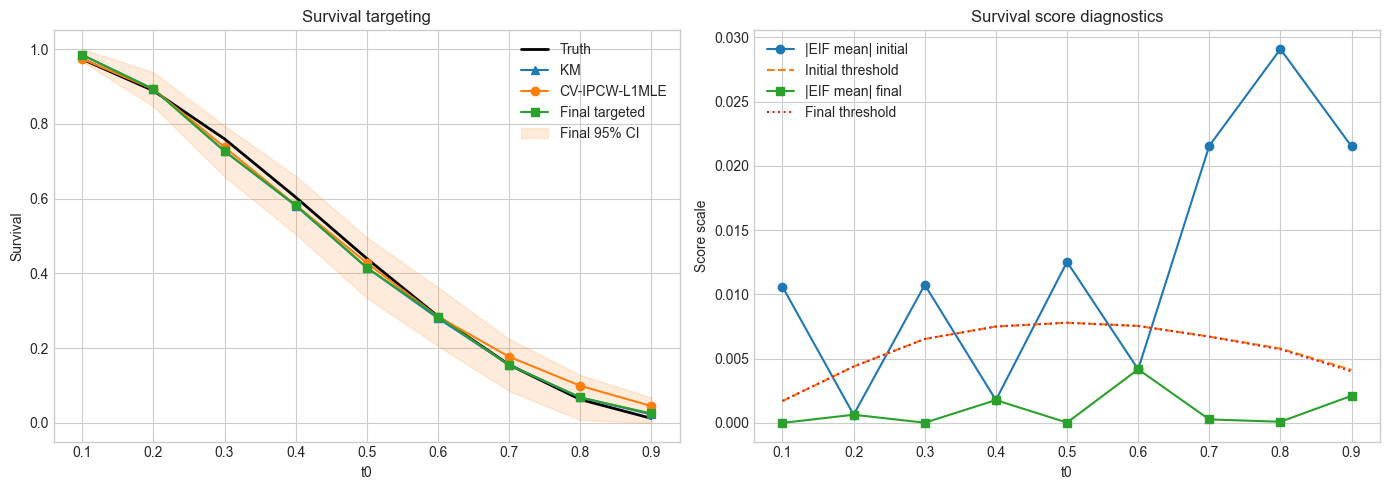

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
demo.plot_target_estimates(TARGET_TYPE, augmented_summary, ax=axes[0])
demo.plot_score_diagnostics(TARGET_TYPE, augmented_summary, ax=axes[1])
plt.tight_layout()
plt.show()


## Single-Target Monte Carlo Check

This is the original small MC check for the currently selected target.


In [7]:
if MC_REPS <= 0:
    mc_result = None
    print('Set MC_REPS > 0 to run the small Monte Carlo check.')
else:
    mc_result = demo.run_small_mc(
        TARGET_TYPE,
        n_reps=MC_REPS,
        n=MC_N,
        base_seed=MC_BASE_SEED,
        target_grid=demo.target_grid_for_type(TARGET_TYPE, shared_grid=TARGET_GRID),
        simulation_kwargs=SIMULATION_KWARGS,
        initial_fit_kwargs=MC_INITIAL_FIT_KWARGS,
        targeting_options=TARGETING_OPTIONS,
        n_workers=MC_N_WORKERS,
        show_progress=MC_SHOW_PROGRESS,
    )
    display(mc_result['metrics'])


Survival MC:   0%|          | 0/100 [00:00<?, ?it/s]/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjus

,stage,truth,mean_estimate,bias,variance,mse,oracle_sd,oracle_coverage,n_replicates,t0
0,km,0.972839,0.975341,0.002502,0.000198,0.000202,0.014075,0.97,100,0.1
1,initial,0.972839,0.962984,-0.009855,0.000131,0.000227,0.011439,0.84,100,0.1
2,final,0.972839,0.975278,0.002438,0.000196,0.000200,0.013987,0.94,100,0.1
3,km,0.888675,0.893953,0.005278,0.000878,0.000897,0.029635,0.96,100,0.2
4,initial,0.888675,0.889116,0.000441,0.000674,0.000667,0.025962,0.96,100,0.2
5,final,0.888675,0.893529,0.004854,0.000885,0.000900,0.029746,0.96,100,0.2
6,km,0.759777,0.763045,0.003268,0.002376,0.002363,0.048741,0.95,100,0.3
7,initial,0.759777,0.766066,0.006289,0.001773,0.001794,0.042102,0.94,100,0.3
8,final,0.759777,0.763164,0.003387,0.002344,0.002332,0.048417,0.95,100,0.3
9,km,0.603920,0.607645,0.003725,0.003393,0.003373,0.058248,0.95,100,0.4


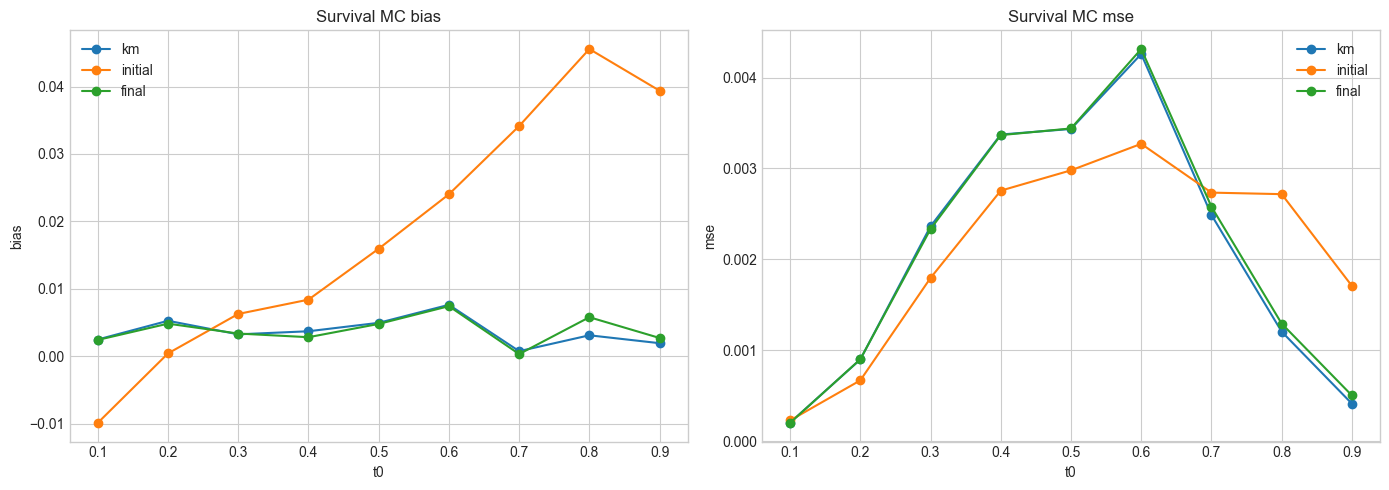

In [8]:
if mc_result is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    demo.plot_mc_metrics(TARGET_TYPE, mc_result['metrics'], metric='bias', ax=axes[0])
    demo.plot_mc_metrics(TARGET_TYPE, mc_result['metrics'], metric='mse', ax=axes[1])
    plt.tight_layout()
    plt.show()


## All Four Target Demos

This section reuses the same one-data-set fit and runs all four targeters side by side.


In [9]:
all_target_demo = None
if RUN_ALL_TARGET_DEMOS:
    all_target_demo = demo.run_all_target_demos(
        sim=sim,
        initial_fit=initial_fit,
        shared_grid=TARGET_GRID,
        targeting_options=TARGETING_OPTIONS,
    )
    display(demo.combine_demo_display_summaries(all_target_demo))
else:
    print('Set RUN_ALL_TARGET_DEMOS = True to run the batch demo section.')


,target_type,t0,truth,psi_km,psi_init,psi_one_step,psi_final,km_bias,plugin_bias,targeted_bias,passes_initial_threshold,status_one_step,n_iterations,stop_reason,tau
0,Survival,0.1,0.972839,0.984280,0.973662,0.984261,0.984261,0.011440,0.000823,0.011422,False,score_tolerance,1,score_tolerance,NaN
1,Survival,0.2,0.888675,0.893266,0.892606,0.892606,0.892606,0.004591,0.003931,0.003931,True,skipped_initial_gate,0,initial_score_tolerance,NaN
2,Survival,0.3,0.759777,0.727015,0.737728,0.726954,0.726954,-0.032762,-0.022049,-0.032823,False,score_tolerance,1,score_tolerance,NaN
3,Survival,0.4,0.603920,0.581097,0.582851,0.582851,0.582851,-0.022823,-0.021069,-0.021069,True,skipped_initial_gate,0,initial_score_tolerance,NaN
4,Survival,0.5,0.439826,0.415446,0.427974,0.415395,0.415395,-0.024380,-0.011852,-0.024431,False,score_tolerance,1,score_tolerance,NaN
5,Survival,0.6,0.285265,0.280163,0.284431,0.284431,0.284431,-0.005102,-0.000834,-0.000834,True,skipped_initial_gate,0,initial_score_tolerance,NaN
6,Survival,0.7,0.155663,0.155288,0.177133,0.154939,0.154939,-0.000375,0.021470,-0.000725,False,score_tolerance,1,score_tolerance,NaN
7,Survival,0.8,0.062675,0.068327,0.099363,0.067985,0.067985,0.005652,0.036688,0.005311,False,score_tolerance,1,score_tolerance,NaN
8,Survival,0.9,0.012194,0.022776,0.045175,0.025240,0.025240,0.010582,0.032981,0.013046,False,score_tolerance,1,score_tolerance,NaN
9,RMST,NaN,0.099129,0.099369,0.098683,0.099368,0.099368,0.000240,-0.000446,0.000240,False,score_tolerance,1,score_tolerance,0.1


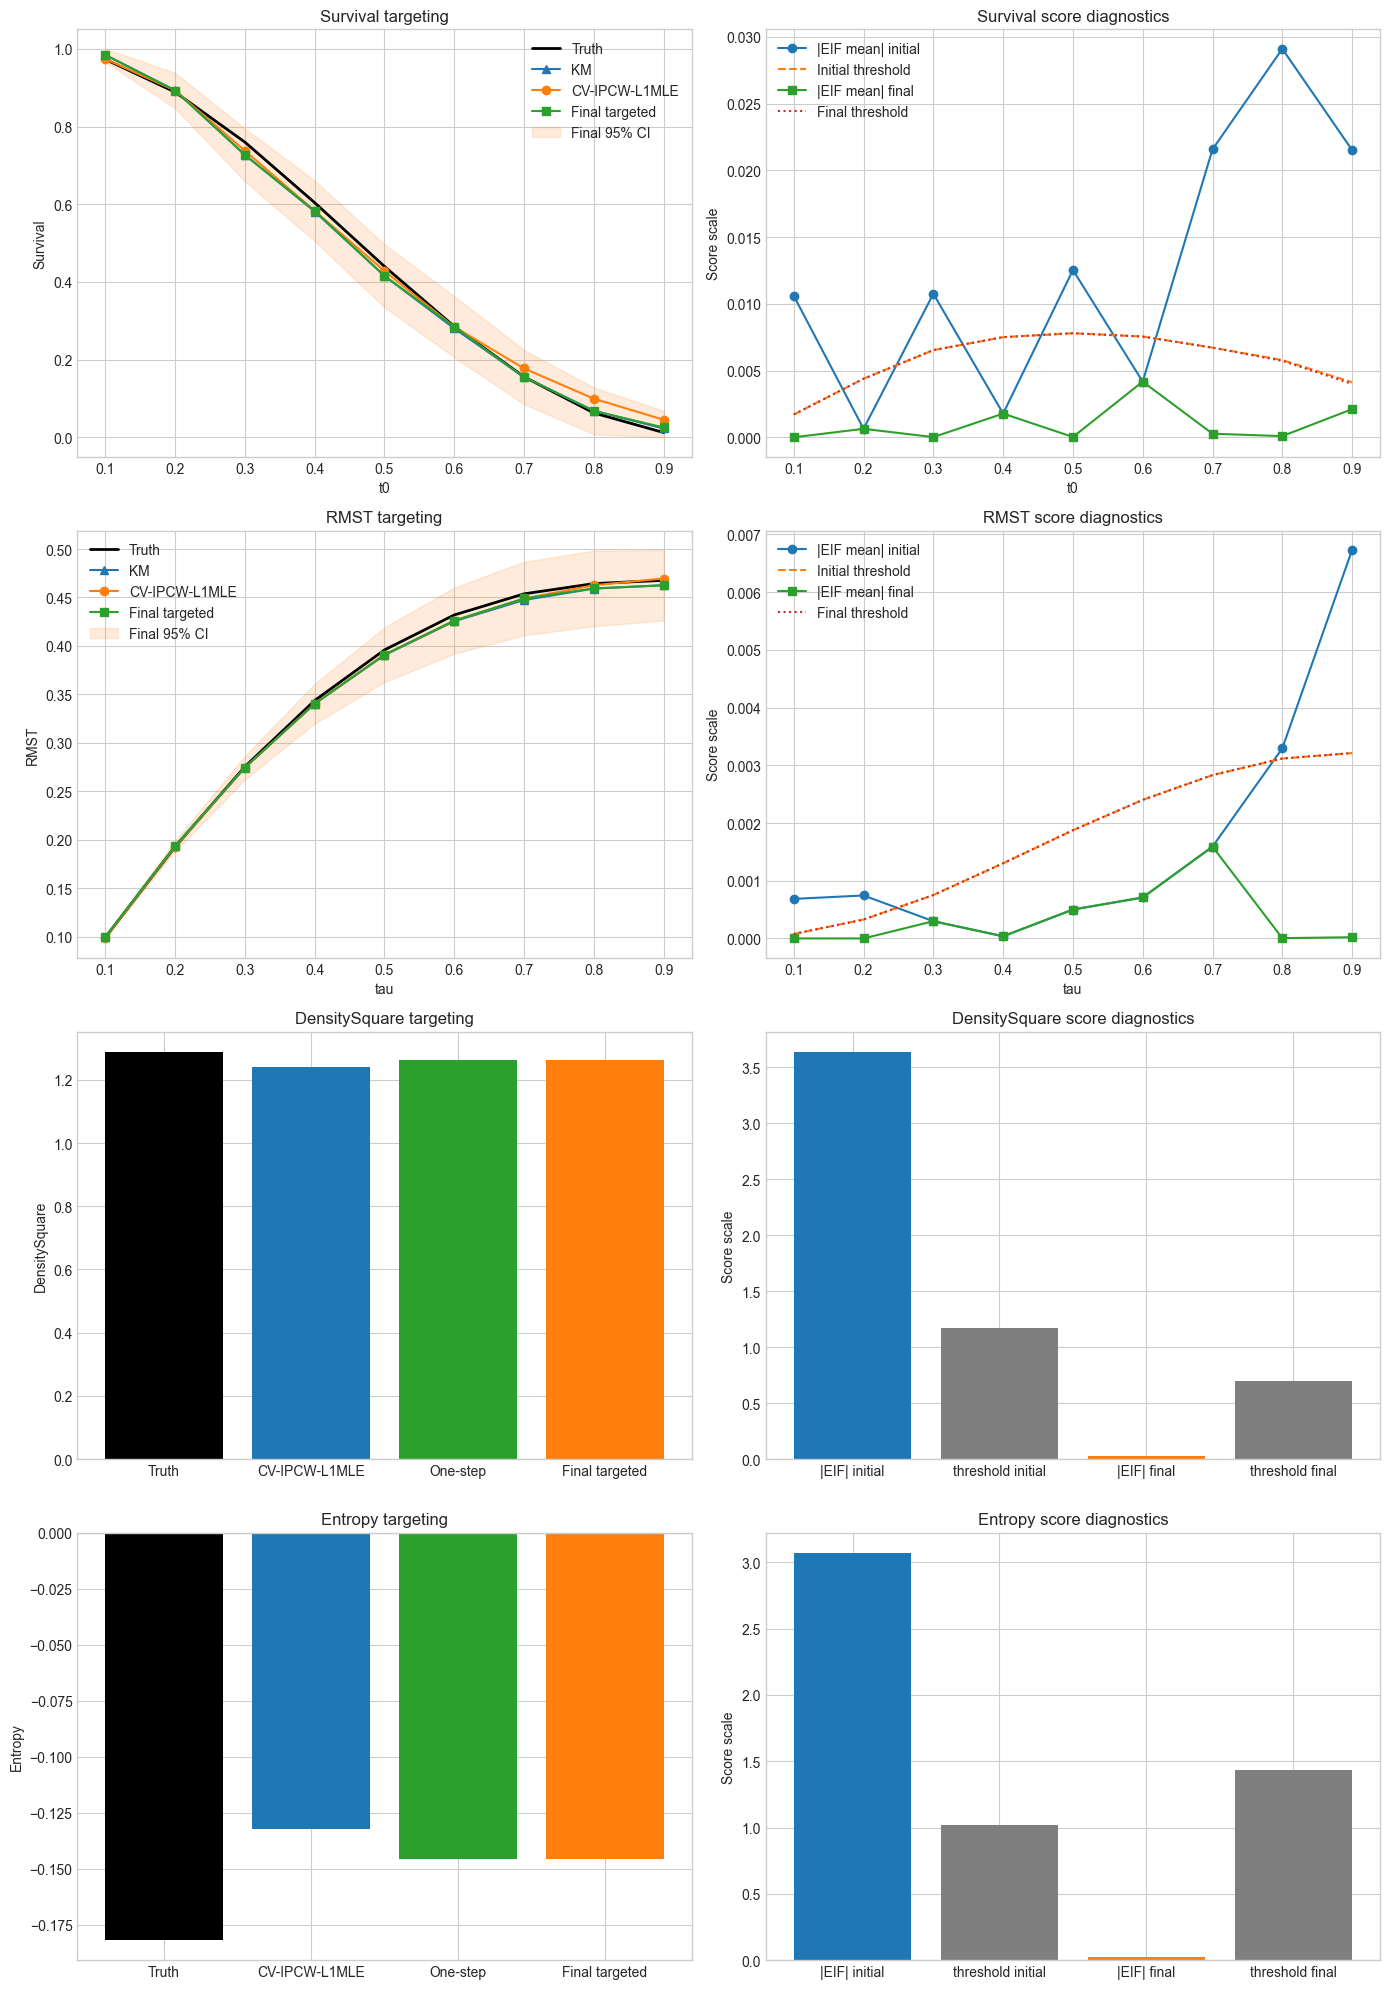

In [10]:
if all_target_demo is not None:
    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    for row_idx, target_name in enumerate(demo.TARGET_OPTIONS):
        result = all_target_demo[target_name]
        demo.plot_target_estimates(target_name, result['augmented_summary'], ax=axes[row_idx, 0])
        demo.plot_score_diagnostics(target_name, result['augmented_summary'], ax=axes[row_idx, 1])
    plt.tight_layout()
    plt.show()


## All Four Monte Carlo Checks

This runs the same small MC template for all four targets. Survival and RMST reuse the same grid. Density-square and entropy are scalar summaries.


In [11]:
all_target_mc = None
if RUN_ALL_TARGET_MC and MC_REPS > 0:
    all_target_mc = demo.run_all_target_small_mc(
        n_reps=MC_REPS,
        n=MC_N,
        base_seed=MC_BASE_SEED,
        shared_grid=TARGET_GRID,
        simulation_kwargs=SIMULATION_KWARGS,
        initial_fit_kwargs=MC_INITIAL_FIT_KWARGS,
        targeting_options=TARGETING_OPTIONS,
        n_workers=MC_N_WORKERS,
        show_progress=MC_SHOW_PROGRESS,
    )
    display(demo.mc_metric_overview(all_target_mc))
else:
    print('Set RUN_ALL_TARGET_MC = True and MC_REPS > 0 to run the all-target MC section.')


All-target MC:   0%|          | 0/100 [00:00<?, ?it/s]/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adj

,target_type,stage,t0,tau,target,bias,variance,mse,oracle_coverage,n_replicates
0,Survival,km,0.1,NaN,NaN,0.002502,1.980922e-04,2.023704e-04,0.97,100
1,Survival,initial,0.1,NaN,NaN,-0.009855,1.308433e-04,2.266580e-04,0.84,100
2,Survival,final,0.1,NaN,NaN,0.002438,1.956258e-04,1.996153e-04,0.94,100
3,Survival,km,0.2,NaN,NaN,0.005278,8.782184e-04,8.972947e-04,0.96,100
4,Survival,initial,0.2,NaN,NaN,0.000441,6.740275e-04,6.674819e-04,0.96,100
5,Survival,final,0.2,NaN,NaN,0.004854,8.848174e-04,8.995267e-04,0.96,100
6,Survival,km,0.3,NaN,NaN,0.003268,2.375679e-03,2.362601e-03,0.95,100
7,Survival,initial,0.3,NaN,NaN,0.006289,1.772593e-03,1.794421e-03,0.94,100
8,Survival,final,0.3,NaN,NaN,0.003387,2.344216e-03,2.332242e-03,0.95,100
9,Survival,km,0.4,NaN,NaN,0.003725,3.392873e-03,3.372822e-03,0.95,100


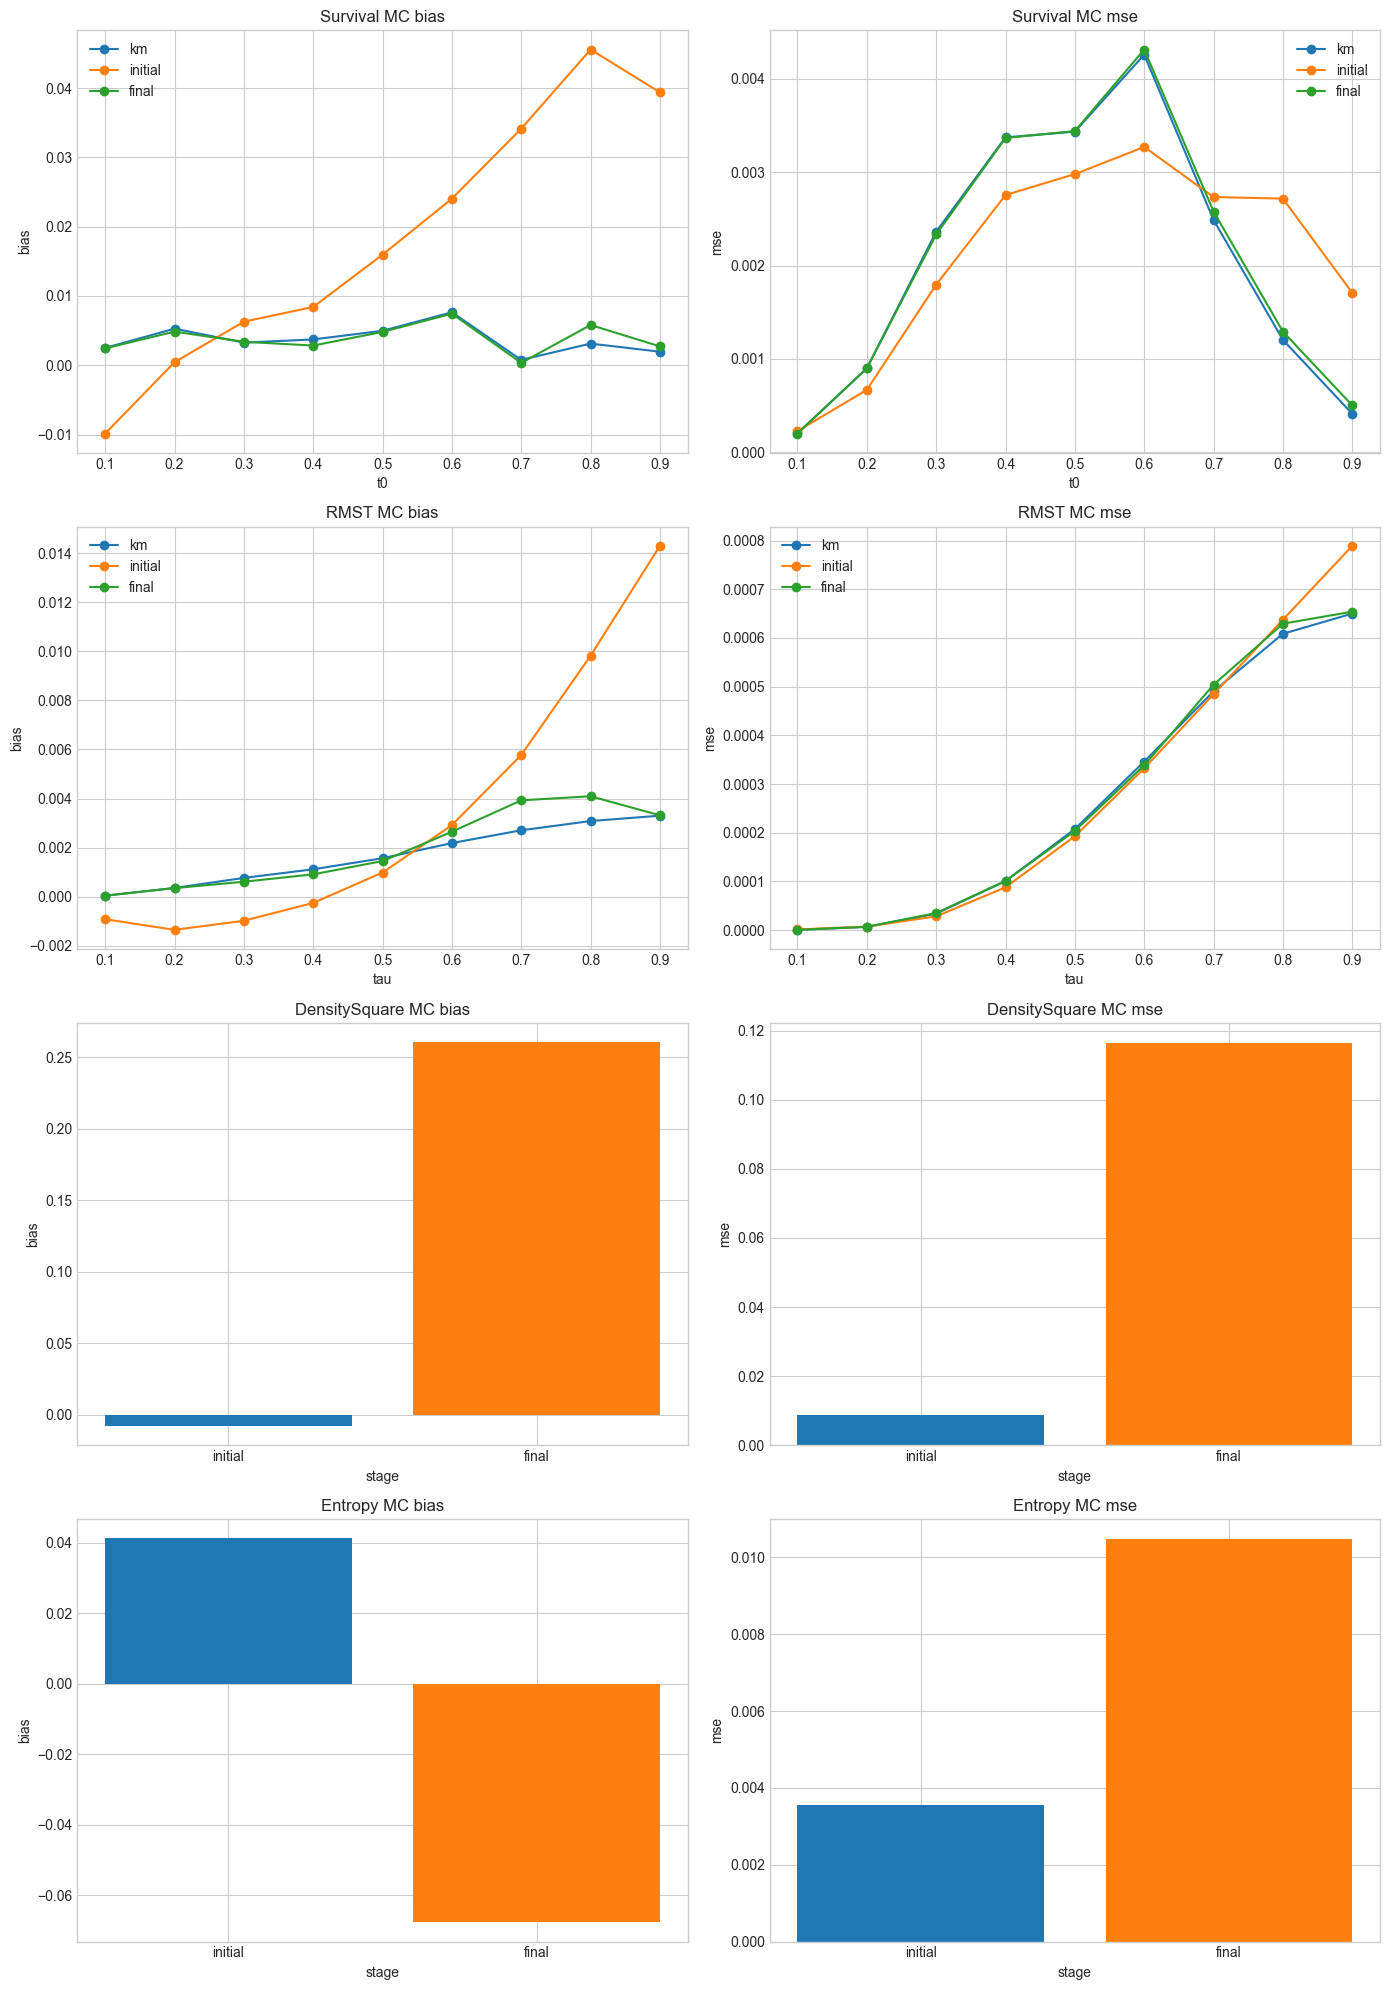

In [12]:
if all_target_mc is not None:
    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    for row_idx, target_name in enumerate(demo.TARGET_OPTIONS):
        target_metrics = all_target_mc['by_target'][target_name]['metrics']
        demo.plot_mc_metrics(target_name, target_metrics, metric='bias', ax=axes[row_idx, 0])
        demo.plot_mc_metrics(target_name, target_metrics, metric='mse', ax=axes[row_idx, 1])
    plt.tight_layout()
    plt.show()
